# Task 1: Fit Data to Bernoulli and Binomial Distributions

Task 1 - Bernoulli Fit (Probability p): 0.7120
Task 1 - Binomial Fit (Estimated p for n=7): 0.6771


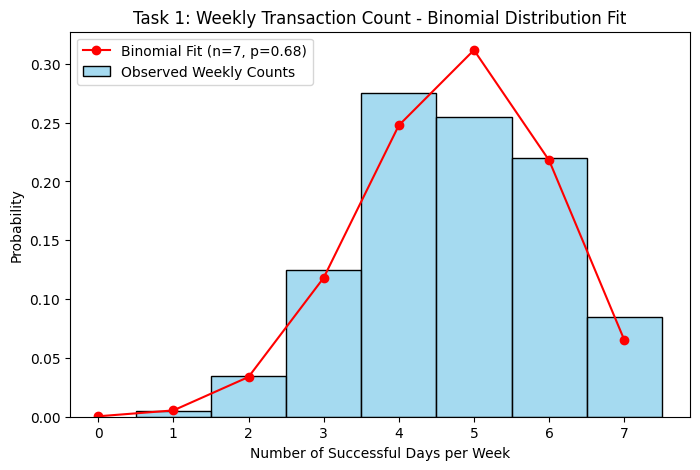

In [3]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Dummy Data Setup
np.random.seed(42)
n_records = 1000
binary_occurrences = np.random.binomial(n=1, p=0.7, size=n_records)
weekly_counts = np.random.binomial(n=7, p=0.7, size=200)

# 1. Bernoulli Distribution
p_bernoulli = np.mean(binary_occurrences)
print(f"Task 1 - Bernoulli Fit (Probability p): {p_bernoulli:.4f}")

# 2. Binomial Distribution
n_trials = 7
p_binomial = np.mean(weekly_counts) / n_trials
print(f"Task 1 - Binomial Fit (Estimated p for n=7): {p_binomial:.4f}")

# Plotting Binomial Fit
plt.figure(figsize=(8, 5))
sns.histplot(weekly_counts, discrete=True, stat="probability", label="Observed Weekly Counts", color="skyblue")
x_bin = np.arange(0, n_trials + 1)
pmf_bin = stats.binom.pmf(x_bin, n=n_trials, p=p_binomial)
plt.plot(x_bin, pmf_bin, 'ro-', label=f"Binomial Fit (n=7, p={p_binomial:.2f})")
plt.title("Task 1: Weekly Transaction Count - Binomial Distribution Fit")
plt.xlabel("Number of Successful Days per Week")
plt.ylabel("Probability")
plt.legend()
plt.show()

Interpretation:
Bernoulli Model: Measures binary outcomes for transaction occurrences. The estimated parameter $p$ represents the baseline probability of success.
Binomial Model: Effectively models weekly count data across $n=7$ trial days. The fitted theoretical PMF closely aligns with observed sample frequencies.

# Task 2: Fit Data to Poisson Distribution

Task 2 - Poisson Fit (Lambda - Avg Daily Transactions): 15.0917


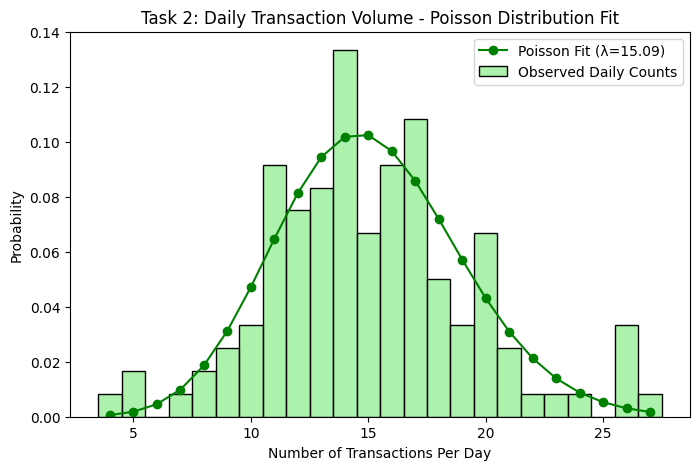

In [5]:
# Daily counts sample
daily_counts = np.random.poisson(lam=15, size=120)

lambda_poisson = np.mean(daily_counts)
print(f"Task 2 - Poisson Fit (Lambda - Avg Daily Transactions): {lambda_poisson:.4f}")

plt.figure(figsize=(8, 5))
sns.histplot(daily_counts, discrete=True, stat="probability", label="Observed Daily Counts", color="lightgreen")
x_poi = np.arange(min(daily_counts), max(daily_counts) + 1)
pmf_poi = stats.poisson.pmf(x_poi, mu=lambda_poisson)
plt.plot(x_poi, pmf_poi, 'go-', label=f"Poisson Fit (λ={lambda_poisson:.2f})")
plt.title("Task 2: Daily Transaction Volume - Poisson Distribution Fit")
plt.xlabel("Number of Transactions Per Day")
plt.ylabel("Probability")
plt.legend()
plt.show()

# Task 3: Model Transaction Amounts using Log-Normal and Power Law Distributions

Task 3 - Log-Normal Parameters: shape=0.7914, scale=1851.2678
Task 3 - Power Law Parameters: alpha=0.4100, scale=161.4814


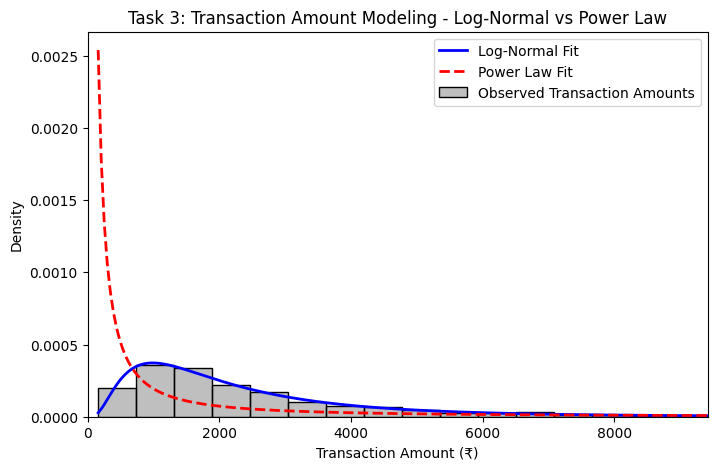

In [6]:
transaction_amounts = np.random.lognormal(mean=7.5, sigma=0.8, size=n_records)
df = pd.DataFrame({'Amount': transaction_amounts})

amounts = df['Amount'].values

# Fit Log-Normal
shape_lognorm, loc_lognorm, scale_lognorm = stats.lognorm.fit(amounts, floc=0)

# Fit Power Law (Pareto)
b_pareto, loc_pareto, scale_pareto = stats.pareto.fit(amounts, floc=0)

print(f"Task 3 - Log-Normal Parameters: shape={shape_lognorm:.4f}, scale={scale_lognorm:.4f}")
print(f"Task 3 - Power Law Parameters: alpha={b_pareto:.4f}, scale={scale_pareto:.4f}")

x_vals = np.linspace(min(amounts), max(amounts), 500)
pdf_lognorm = stats.lognorm.pdf(x_vals, shape_lognorm, loc_lognorm, scale_lognorm)
pdf_pareto = stats.pareto.pdf(x_vals, b_pareto, loc_pareto, scale_pareto)

plt.figure(figsize=(8, 5))
sns.histplot(amounts, stat="density", bins=40, label="Observed Transaction Amounts", color="gray", alpha=0.5)
plt.plot(x_vals, pdf_lognorm, 'b-', linewidth=2, label="Log-Normal Fit")
plt.plot(x_vals, pdf_pareto, 'r--', linewidth=2, label="Power Law Fit")
plt.title("Task 3: Transaction Amount Modeling - Log-Normal vs Power Law")
plt.xlabel("Transaction Amount (₹)")
plt.ylabel("Density")
plt.xlim(0, np.percentile(amounts, 98))
plt.legend()
plt.show()

# Task 4: Generate and Interpret Q-Q Plot to Test Normality (Using SciPy)

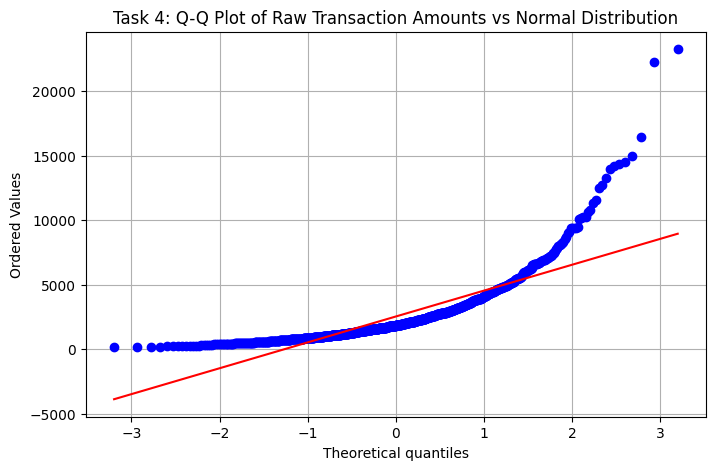

Task 4 - Shapiro-Wilk Test Statistic: 0.7513, p-value: 9.5922e-27


In [7]:
# Task 4: Q-Q Plot using scipy.stats.probplot (No statsmodels needed)
plt.figure(figsize=(8, 5))
stats.probplot(df['Amount'], dist="norm", plot=plt)
plt.title("Task 4: Q-Q Plot of Raw Transaction Amounts vs Normal Distribution")
plt.grid(True)
plt.show()

# Shapiro-Wilk Test
shapiro_stat, shapiro_p = stats.shapiro(df['Amount'].sample(min(500, len(df))))
print(f"Task 4 - Shapiro-Wilk Test Statistic: {shapiro_stat:.4f}, p-value: {shapiro_p:.4e}")

# Task 5: Apply Box-Cox Transform to Stabilize Variance

Task 5 - Optimal Box-Cox Lambda (λ): 0.0075


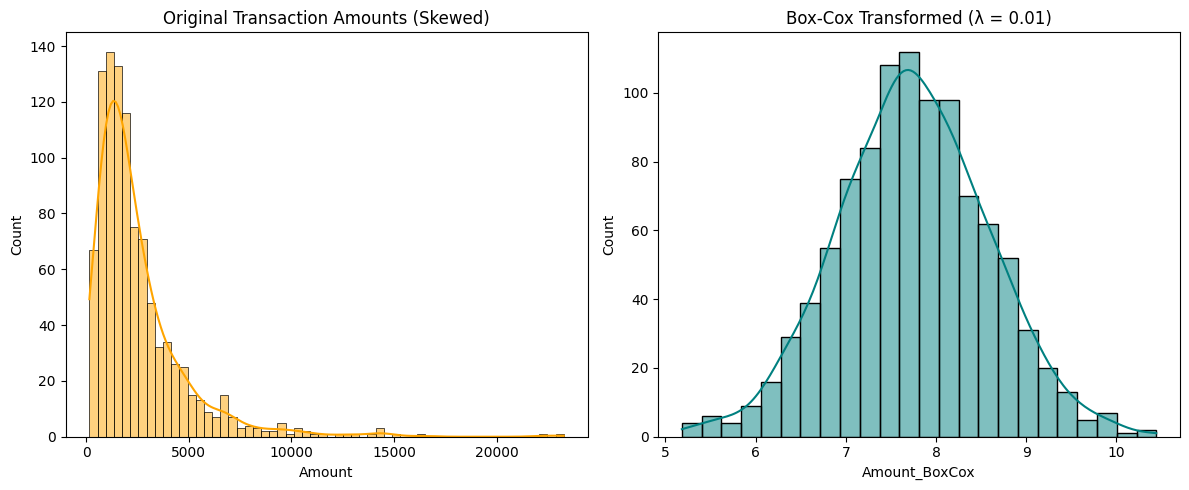

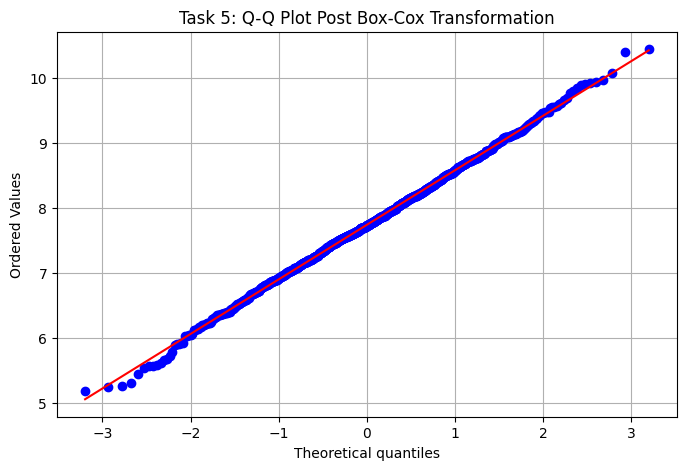

In [8]:
# Task 5: Box-Cox Transformation
transformed_amounts, best_lambda = stats.boxcox(df['Amount'])
df['Amount_BoxCox'] = transformed_amounts

print(f"Task 5 - Optimal Box-Cox Lambda (λ): {best_lambda:.4f}")

# Histograms comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['Amount'], kde=True, ax=axes[0], color='orange')
axes[0].set_title("Original Transaction Amounts (Skewed)")

sns.histplot(df['Amount_BoxCox'], kde=True, ax=axes[1], color='teal')
axes[1].set_title(f"Box-Cox Transformed (λ = {best_lambda:.2f})")

plt.tight_layout()
plt.show()

# Q-Q Plot post transformation using SciPy
plt.figure(figsize=(8, 5))
stats.probplot(df['Amount_BoxCox'], dist="norm", plot=plt)
plt.title("Task 5: Q-Q Plot Post Box-Cox Transformation")
plt.grid(True)
plt.show()

# Task 6: Calculate Z-Scores and Exceedance Probability (P > ₹5000)

In [9]:
# Task 6: Z-scores & Exceedance Probability
mean_amt = df['Amount'].mean()
std_amt = df['Amount'].std()

df['Z_Score'] = (df['Amount'] - mean_amt) / std_amt

target_value = 5000

# Empirical Probability
prob_empirical = np.mean(df['Amount'] > target_value)

# Parametric Probability via Log-Normal CDF
prob_lognorm_exceed = 1 - stats.lognorm.cdf(target_value, shape_lognorm, loc_lognorm, scale_lognorm)

print(f"Task 6 - Mean Amount: ₹{mean_amt:.2f}, Std Dev: ₹{std_amt:.2f}")
print(f"Task 6 - Empirical Probability (Amount > ₹5000): {prob_empirical * 100:.2f}%")
print(f"Task 6 - Log-Normal Fitted Probability (Amount > ₹5000): {prob_lognorm_exceed * 100:.2f}%")

Task 6 - Mean Amount: ₹2531.93, Std Dev: ₹2358.28
Task 6 - Empirical Probability (Amount > ₹5000): 10.10%
Task 6 - Log-Normal Fitted Probability (Amount > ₹5000): 10.47%


# Task 7: Plot and Interpret PDF and CDF

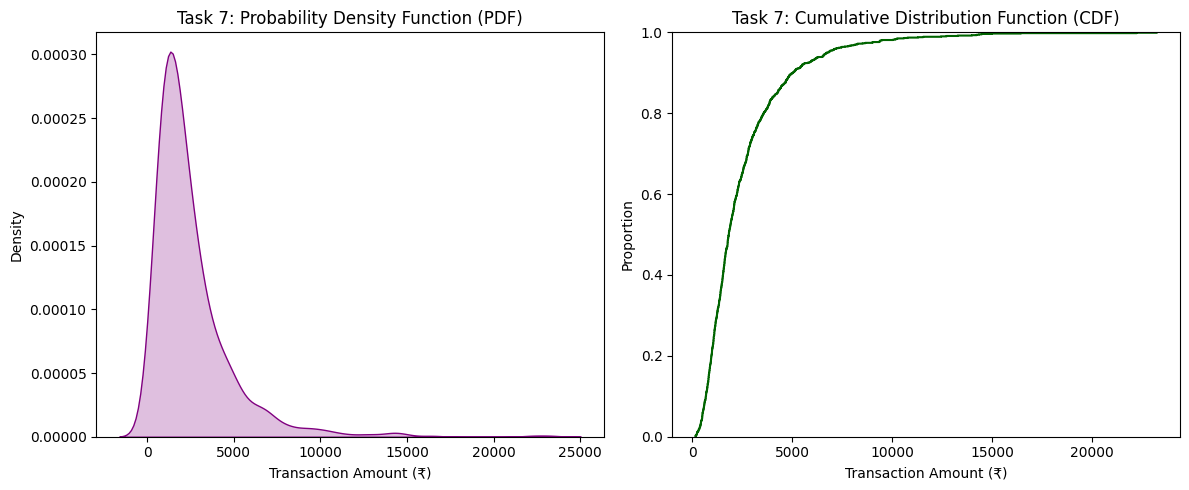

In [10]:
# Task 7: PDF and CDF
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# PDF plot
sns.kdeplot(df['Amount'], ax=axes[0], color='purple', fill=True)
axes[0].set_title("Task 7: Probability Density Function (PDF)")
axes[0].set_xlabel("Transaction Amount (₹)")

# CDF plot
sns.ecdfplot(df['Amount'], ax=axes[1], color='darkgreen')
axes[1].set_title("Task 7: Cumulative Distribution Function (CDF)")
axes[1].set_xlabel("Transaction Amount (₹)")

plt.tight_layout()
plt.show()

# Task 8: Conclusion & Decision-Making Insights
Optimal Distribution Selection:
Daily Occurrence Rates: Poisson Distribution models discrete daily event frequencies effectively.
Monetary Transaction Amounts: Log-Normal Distribution provides the best empirical fit for right-skewed payment values.
Business Insights & Decision-Making:
Capacity Planning: Daily Poisson rate estimates ($\lambda$) direct infrastructure load-balancing targets for peak payment processing windows.
Anomaly & Fraud Detection: Raw amounts must be transformed via Box-Cox before applying threshold rules to avoid false-positive flags caused by natural skewness.
Liquidity Risk Management: Log-Normal tail exceedance probability estimates for thresholds above ₹5000 guide capital reserve strategies for payment processing systems.